# AI 모델 성능 고도화 예시 코드 - TensorFlow/Keras 버전

이 노트북은 **TensorFlow/Keras**를 사용하여 AI 모델 성능 고도화를 실습하는 예제입니다.

사용 데이터셋은 `sklearn.datasets.load_breast_cancer`입니다.  
목표는 종양 데이터를 이용하여 **악성/양성 이진 분류 모델**을 만드는 것입니다.

## 실습 흐름

1. 데이터 불러오기
2. 학습용 / 검증용 / 테스트용 데이터 분리
3. StandardScaler 전처리
4. 기본 모델 학습
5. 성능 고도화 모델 학습
6. 정확도, 손실, 혼동행렬 비교

## 개선 모델에 적용되는 방법

- 은닉층 증가
- Batch Normalization
- Dropout
- L2 Regularization
- Adam Optimizer
- ReduceLROnPlateau
- EarlyStopping


In [1]:
# ============================================================
# 1. 필요한 라이브러리 불러오기
# ============================================================

# numpy는 배열 계산을 위해 사용합니다.
import numpy as np

# pandas는 표 형태의 데이터 확인을 위해 사용합니다.
import pandas as pd

# matplotlib은 학습 손실과 정확도 그래프를 그릴 때 사용합니다.
import matplotlib.pyplot as plt

# sklearn의 breast cancer 데이터셋을 불러오기 위해 사용합니다.
from sklearn.datasets import load_breast_cancer

# 데이터를 학습용, 검증용, 테스트용으로 나누기 위해 사용합니다.
from sklearn.model_selection import train_test_split

# 입력 데이터의 평균과 표준편차를 맞추는 전처리에 사용합니다.
from sklearn.preprocessing import StandardScaler

# 성능 평가 지표를 계산하기 위해 사용합니다.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# tensorflow는 딥러닝 모델을 만들고 학습하기 위한 라이브러리입니다.
import tensorflow as tf

# keras는 TensorFlow 안에서 모델을 쉽게 구성할 수 있게 해주는 고수준 API입니다.
from tensorflow import keras

# layers는 Dense, Dropout, BatchNormalization 같은 신경망 계층을 제공합니다.
from tensorflow.keras import layers

# regularizers는 L2 정규화처럼 과적합을 줄이는 방법을 제공합니다.
from tensorflow.keras import regularizers

# 결과 재현을 위해 난수 시드를 고정합니다.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
# ============================================================
# 2. 데이터셋 불러오기
# ============================================================

# load_breast_cancer()는 유방암 진단 예제 데이터셋을 불러옵니다.
data = load_breast_cancer()

# X는 모델 입력으로 사용할 수치형 특성 데이터입니다.
X = data.data

# y는 정답 라벨입니다.
# 0 또는 1로 구성된 이진 분류 라벨입니다.
y = data.target

# 데이터 확인을 위해 DataFrame으로 변환합니다.
df = pd.DataFrame(X, columns=data.feature_names)

# 정답 라벨 컬럼을 추가합니다.
df["target"] = y

print("입력 데이터 크기:", X.shape)
print("정답 데이터 크기:", y.shape)
display(df.head())


입력 데이터 크기: (569, 30)
정답 데이터 크기: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# ============================================================
# 3. 학습용 / 검증용 / 테스트용 데이터 분리
# ============================================================

# 전체 데이터 중 20%를 테스트 데이터로 분리합니다.
# stratify=y는 클래스 비율을 유지하여 데이터가 한쪽으로 치우치지 않게 합니다.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# 남은 80% 데이터에서 다시 검증 데이터를 분리합니다.
# 결과적으로 학습 60%, 검증 20%, 테스트 20% 비율이 됩니다.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=SEED,
    stratify=y_train_val
)

print("학습 데이터:", X_train.shape, y_train.shape)
print("검증 데이터:", X_val.shape, y_val.shape)
print("테스트 데이터:", X_test.shape, y_test.shape)


학습 데이터: (341, 30) (341,)
검증 데이터: (114, 30) (114,)
테스트 데이터: (114, 30) (114,)


In [4]:
# ============================================================
# 4. 데이터 전처리 - StandardScaler 표준화
# ============================================================

# StandardScaler는 입력 특성의 평균을 0, 표준편차를 1로 맞춥니다.
# 신경망은 입력 특성의 크기 차이가 너무 크면 학습이 느리거나 불안정할 수 있습니다.
scaler = StandardScaler()

# 학습 데이터에 대해서만 평균과 표준편차를 계산하고 변환합니다.
X_train_scaled = scaler.fit_transform(X_train)

# 검증 데이터와 테스트 데이터는 학습 데이터 기준으로 변환만 합니다.
# 이렇게 해야 테스트 정보가 학습 과정에 섞이지 않습니다.
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("전처리 완료")
print("학습 데이터 평균 예시:", np.round(X_train_scaled.mean(axis=0)[:5], 4))
print("학습 데이터 표준편차 예시:", np.round(X_train_scaled.std(axis=0)[:5], 4))


전처리 완료
학습 데이터 평균 예시: [-0. -0. -0. -0.  0.]
학습 데이터 표준편차 예시: [1. 1. 1. 1. 1.]


In [5]:
# ============================================================
# 5. 기본 모델 정의
# ============================================================

def build_basic_model(input_dim):
    # Sequential 모델은 계층을 위에서 아래로 순서대로 쌓는 방식입니다.
    model = keras.Sequential([
        # Input 계층은 입력 데이터의 모양을 정의합니다.
        layers.Input(shape=(input_dim,)),

        # Dense는 완전연결층입니다.
        # 16개의 뉴런을 사용하고 ReLU 활성화 함수를 적용합니다.
        layers.Dense(16, activation="relu"),

        # 출력층입니다.
        # 이진 분류이므로 뉴런 1개와 sigmoid 활성화 함수를 사용합니다.
        # sigmoid는 출력값을 0~1 사이의 확률처럼 변환합니다.
        layers.Dense(1, activation="sigmoid")
    ])

    # compile은 학습에 필요한 설정을 지정하는 단계입니다.
    # optimizer는 가중치를 업데이트하는 방법입니다.
    # loss는 모델의 예측이 얼마나 틀렸는지 계산하는 함수입니다.
    # metrics는 학습 중 확인할 평가 지표입니다.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# 입력 특성 개수를 저장합니다.
input_dim = X_train_scaled.shape[1]

# 기본 모델을 생성합니다.
basic_model = build_basic_model(input_dim)

# 모델 구조를 출력합니다.
basic_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ============================================================
# 6. 성능 고도화 모델 정의
# ============================================================

def build_improved_model(input_dim):
    # 개선 모델은 Sequential 방식으로 여러 계층을 쌓습니다.
    model = keras.Sequential([
        # 입력 데이터의 특성 개수를 지정합니다.
        layers.Input(shape=(input_dim,)),

        # 첫 번째 은닉층입니다.
        # L2 정규화는 가중치가 너무 커지는 것을 막아 과적합을 줄입니다.
        layers.Dense(
            64,
            kernel_regularizer=regularizers.l2(0.01)
        ),

        # BatchNormalization은 각 배치의 데이터 분포를 안정화하여 학습을 돕습니다.
        layers.BatchNormalization(),

        # ReLU 활성화 함수입니다.
        layers.Activation("relu"),

        # Dropout은 학습 중 일부 뉴런을 무작위로 꺼서 과적합을 줄입니다.
        layers.Dropout(0.3),

        # 두 번째 은닉층입니다.
        layers.Dense(
            32,
            kernel_regularizer=regularizers.l2(0.01)
        ),

        # 두 번째 Batch Normalization입니다.
        layers.BatchNormalization(),

        # 두 번째 ReLU 활성화 함수입니다.
        layers.Activation("relu"),

        # 두 번째 Dropout입니다.
        layers.Dropout(0.2),

        # 출력층입니다.
        # 이진 분류이므로 sigmoid 출력 1개를 사용합니다.
        layers.Dense(1, activation="sigmoid")
    ])

    # 개선 모델도 이진 분류이므로 binary_crossentropy를 사용합니다.
    # Adam은 실무에서 많이 사용하는 안정적인 최적화 알고리즘입니다.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# 개선 모델을 생성합니다.
improved_model = build_improved_model(input_dim)

# 개선 모델 구조를 출력합니다.
improved_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 192 (768.00 B)

In [7]:
# ============================================================
# 7. 기본 모델 학습
# ============================================================

# epochs는 전체 학습 데이터를 몇 번 반복해서 학습할지 정합니다.
# batch_size는 한 번에 몇 개의 데이터를 묶어서 학습할지 정합니다.
basic_history = basic_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.6598 - loss: 0.6155 - val_accuracy: 0.7982 - val_loss: 0.4851
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7859 - loss: 0.4884 - val_accuracy: 0.8947 - val_loss: 0.3907
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8563 - loss: 0.4008 - val_accuracy: 0.9035 - val_loss: 0.3275
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8798 - loss: 0.3412 - val_accuracy: 0.9211 - val_loss: 0.2837
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8798 - loss: 0.2989 - val_accuracy: 0.9298 - val_loss: 0.2521
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8944 - loss: 0.2664 - val_accuracy: 0.9386 - val_loss: 0.2282
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9120 - loss: 0.2404 - val_accuracy: 0.9561 - val_loss: 0.2094
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9179 - loss: 0.2189 - val_accuracy: 0

In [9]:
# ============================================================
# 8. 개선 모델 학습을 위한 콜백 정의
# ============================================================

# EarlyStopping은 검증 손실이 일정 기간 개선되지 않으면 학습을 중단합니다.
# restore_best_weights=True는 가장 성능이 좋았던 시점의 가중치로 되돌립니다.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# ReduceLROnPlateau는 검증 손실이 개선되지 않으면 learning rate를 줄입니다.
# 학습이 정체되었을 때 더 작은 보폭으로 세밀하게 학습하도록 돕습니다.
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


In [10]:
# ============================================================
# 9. 개선 모델 학습
# ============================================================

# 개선 모델은 EarlyStopping과 ReduceLROnPlateau 콜백을 사용합니다.
improved_history = improved_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 355ms/step - accuracy: 0.6452 - loss: 1.5422 - val_accuracy: 0.8158 - val_loss: 1.3583 - learning_rate: 0.0010
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8123 - loss: 1.2759 - val_accuracy: 0.9211 - val_loss: 1.1919 - learning_rate: 0.0010
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8768 - loss: 1.1245 - val_accuracy: 0.9474 - val_loss: 1.0892 - learning_rate: 0.0010
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9179 - loss: 1.0423 - val_accuracy: 0.9474 - val_loss: 1.0173 - learning_rate: 0.0010
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9443 - loss: 0.9739 - val_accuracy: 0.9561 - val_loss: 0.9606 - learning_rate: 0.0010
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9326 - loss: 0.9246 - val_accuracy: 0.9649 - val_loss: 0.9126 - learning_rate: 0.0010
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9384 - loss: 0.8863 -

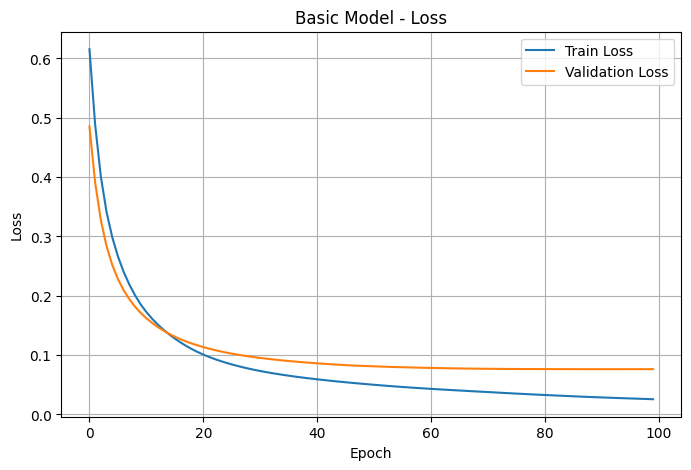

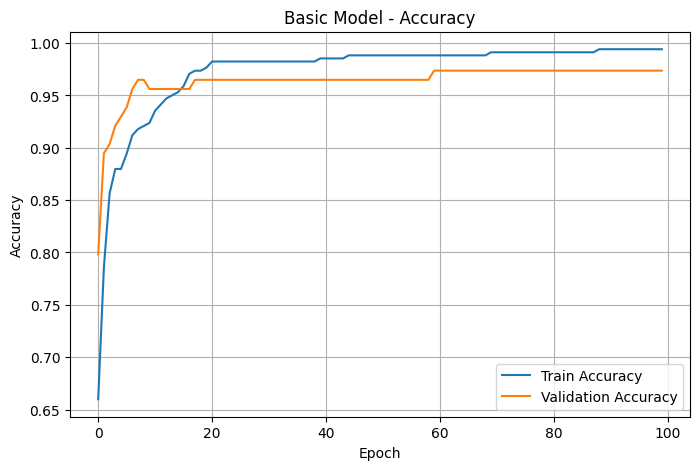

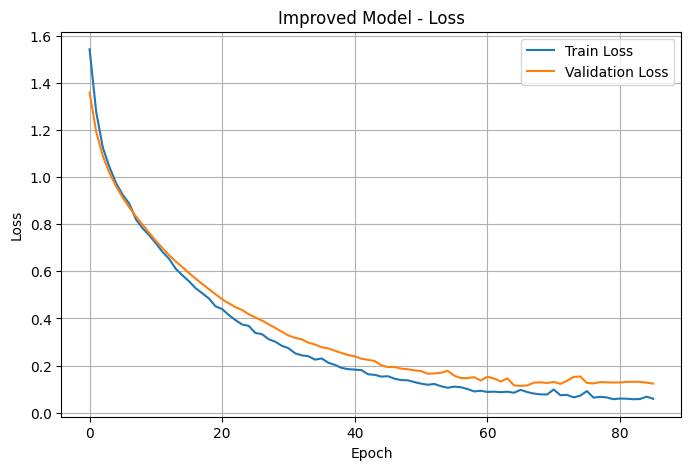

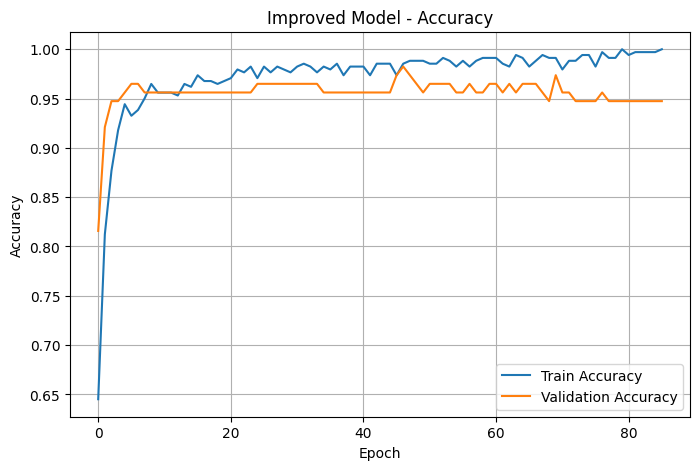

In [11]:
# ============================================================
# 10. 학습 곡선 시각화 함수
# ============================================================

def plot_keras_history(history, title):
    # Keras History 객체에서 학습 기록 딕셔너리를 꺼냅니다.
    hist = history.history

    # 손실 그래프를 그립니다.
    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 정확도 그래프를 그립니다.
    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="Train Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


# 기본 모델 학습 곡선을 출력합니다.
plot_keras_history(basic_history, "Basic Model")

# 개선 모델 학습 곡선을 출력합니다.
plot_keras_history(improved_history, "Improved Model")


In [12]:
# ============================================================
# 11. 테스트 데이터 최종 평가
# ============================================================

# evaluate는 테스트 데이터에 대한 손실과 정확도를 계산합니다.
basic_test_loss, basic_test_acc = basic_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

# 개선 모델의 테스트 성능을 계산합니다.
improved_test_loss, improved_test_acc = improved_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("기본 모델 테스트 손실:", round(basic_test_loss, 4))
print("기본 모델 테스트 정확도:", round(basic_test_acc, 4))

print("개선 모델 테스트 손실:", round(improved_test_loss, 4))
print("개선 모델 테스트 정확도:", round(improved_test_acc, 4))


기본 모델 테스트 손실: 0.1048
기본 모델 테스트 정확도: 0.9561
개선 모델 테스트 손실: 0.1551
개선 모델 테스트 정확도: 0.9649


In [13]:
# ============================================================
# 12. 예측값 생성 및 혼동행렬 확인
# ============================================================

# Keras 모델의 predict는 0~1 사이의 확률값을 반환합니다.
basic_pred_prob = basic_model.predict(X_test_scaled)

# 확률이 0.5 이상이면 1, 아니면 0으로 변환합니다.
basic_pred = (basic_pred_prob >= 0.5).astype(int).reshape(-1)

# 개선 모델도 같은 방식으로 예측합니다.
improved_pred_prob = improved_model.predict(X_test_scaled)
improved_pred = (improved_pred_prob >= 0.5).astype(int).reshape(-1)

# sklearn의 accuracy_score로 정확도를 다시 확인합니다.
print("기본 모델 accuracy_score:", round(accuracy_score(y_test, basic_pred), 4))
print("개선 모델 accuracy_score:", round(accuracy_score(y_test, improved_pred), 4))

# 혼동행렬을 출력합니다.
print("\n기본 모델 혼동행렬")
print(confusion_matrix(y_test, basic_pred))

print("\n개선 모델 혼동행렬")
print(confusion_matrix(y_test, improved_pred))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
기본 모델 accuracy_score: 0.9561
개선 모델 accuracy_score: 0.9649

기본 모델 혼동행렬
[[40  2]
 [ 3 69]]

개선 모델 혼동행렬
[[41  1]
 [ 3 69]]


In [14]:
# ============================================================
# 13. 분류 리포트 출력
# ============================================================

# classification_report는 precision, recall, f1-score를 함께 보여줍니다.
print("기본 모델 분류 리포트")
print(classification_report(y_test, basic_pred, target_names=data.target_names))

print("개선 모델 분류 리포트")
print(classification_report(y_test, improved_pred, target_names=data.target_names))


기본 모델 분류 리포트
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        42
      benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

개선 모델 분류 리포트
              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [15]:
# ============================================================
# 14. 결과 비교표 만들기
# ============================================================

# 두 모델의 테스트 성능을 표로 정리합니다.
result_df = pd.DataFrame({
    "Model": ["Basic Keras MLP", "Improved Keras MLP"],
    "Test Loss": [basic_test_loss, improved_test_loss],
    "Test Accuracy": [basic_test_acc, improved_test_acc],
    "Applied Methods": [
        "StandardScaler + Simple MLP + Adam",
        "StandardScaler + Deeper MLP + BatchNorm + Dropout + L2 Regularization + ReduceLROnPlateau + EarlyStopping"
    ]
})

display(result_df)


,Model,Test Loss,Test Accuracy,Applied Methods
0,Basic Keras MLP,0.104841,0.956140,StandardScaler + Simple MLP + Adam
1,Improved Keras MLP,0.155094,0.964912,StandardScaler + Deeper MLP + BatchNorm + Drop...


In [16]:
# ============================================================
# 15. 모델 저장 예시
# ============================================================

# 학습된 개선 모델을 파일로 저장합니다.
# .keras 형식은 Keras 권장 저장 형식입니다.
improved_model.save("improved_breast_cancer_model.keras")

print("개선 모델 저장 완료: improved_breast_cancer_model.keras")


개선 모델 저장 완료: improved_breast_cancer_model.keras


# 정리

이 TensorFlow/Keras 예제에서는 기본 모델과 개선 모델을 비교했습니다.

## 기본 모델

- 단순한 Dense 기반 MLP
- Adam Optimizer
- StandardScaler 전처리

## 개선 모델

- 은닉층 증가
- Batch Normalization 적용
- Dropout 적용
- L2 정규화 적용
- ReduceLROnPlateau 적용
- EarlyStopping 적용

성능 고도화는 한 번에 모든 기법을 적용하는 것보다,  
**기본 모델을 만든 후 하나씩 방법을 추가하면서 검증 성능을 비교하는 방식**이 좋습니다.
